In [1]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

In [109]:
dir_path = 'drop-211025-5'

img_paths = [dir_path + '/'+ f for f in os.listdir(dir_path) if f.endswith('.jpg')]
img_paths.sort()

In [111]:
select = ga.Select(img_paths[-1])
roi_max = select.select_roi()
roi_min = select.select_roi()

path_roi = 'rois-5.txt'

with open(path_roi, 'w') as f:
    f.write(str(roi_max))
    f.write('\n')
    f.write(str(roi_min))

In [112]:
import ast

path_roi = 'rois-5.txt'
with open(path_roi, 'r') as f:
    roi_max = f.readline().strip()
    roi_min = f.readline().strip()

roi_max = ast.literal_eval(roi_max)
roi_min = ast.literal_eval(roi_min)

print(roi_min)
print(roi_max)

(122, 389, 45, 4)
(123, 386, 58, 12)


In [113]:
roi_json = 'roi_json_may27.txt'

with open(roi_json, 'a') as f:
    f.write(json.dumps({'min': roi_min, 'max': roi_max}) + "\n")

In [114]:
fringe_collection = []

for path in img_paths:
    select = ga.SelectRNGArea(path, roi_max = roi_max, roi_min = roi_min, num=50)
    select.get_random_rois()
    fringe_list = select.extract()
    fringe_collection.append(fringe_list)

## Filter out the lowest frequencies

In [115]:
collection_low_ftl = []

for fringe_list in fringe_collection:
    fringe_list_new = fringe_list.filter_low_frq(inplace=False, nl=2)
    collection_low_ftl.append(fringe_list_new)

print(collection_low_ftl[0].list_len)

50


## Using phase unwraping method

In [116]:
frq_collection = []

for lines in collection_low_ftl:
    num_peaks = lines.count_peaks_of_autocorr()
    num = [i-1 for i in num_peaks]
    lines.filter_low_frq(nl=num)
    lines_Wn = lines.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
    frqs = lines_Wn.get_frq(prefilter=False)
    frq_collection.append(frqs)

In [117]:
means = [np.mean(frq) for frq in frq_collection]
stds = [np.std(frq) for frq in frq_collection]

T_collection = [2*np.pi/np.array(frq) for frq in frq_collection]

means_T = [np.mean(T) for T in T_collection]
stds_T = [np.std(T) for T in T_collection]

means_f = [f"{m:.4f}" for m in means]
stds_f = [f"{s:.4f}" for s in stds]
print(means_f)
print(stds_f)

['1.4818', '1.3338', '1.2294', '1.1321', '1.0532', '0.9328', '0.8825', '0.8412', '0.7664', '0.7722', '0.7011', '0.6406', '0.6381', '0.5677']
['0.1025', '0.0978', '0.0943', '0.1079', '0.1389', '0.0759', '0.1017', '0.1292', '0.0798', '0.1634', '0.1591', '0.0896', '0.1465', '0.0901']


In [118]:
# save means (mean frequencies) and stds (standart deviations) into a result file

res_path = 'results.txt'

with open(res_path, 'a') as f:
    f.write(json.dumps({'mean': means, 'std': stds}) + "\n")

res_path_T = 'results_period.txt'

with open(res_path_T, 'a') as f:
    f.write(json.dumps({'mean': means_T, 'std': stds_T}) + "\n")

## Plot the graps of mean_frwqs and their stds

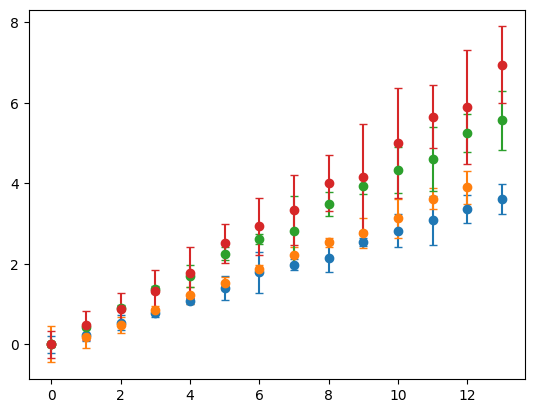

In [119]:
res_path_T = 'results_period.txt'

plt.figure()

with open(res_path_T, 'r') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            x = np.arange(len(data['mean']))
            plt.errorbar(x, np.array(data['mean'])-data['mean'][0], yerr=data['std'],fmt='o', capsize=3)


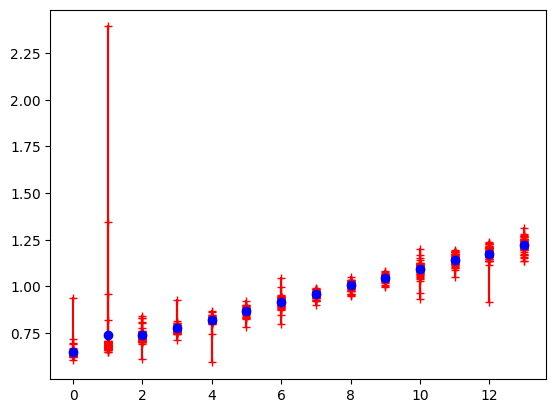

In [27]:
plt.figure()

for i, frqs in enumerate(frq_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()